## 머신러닝

In [45]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [46]:
df_cleaned = pd.read_csv("data/first_clean_data.csv")

## 머신러닝 전용 DF 전처리

In [47]:
df_machine = df_cleaned.copy()
df_machine.head()

,Unnamed: 0,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197


## 컬럼 드랍

In [48]:
drop_cols = ['Unnamed: 0', 'id', 'name', 'description', 'host_id', 'host_since',
        'host_response_time', 'host_acceptance_rate',
        'host_is_superhost', 'neighbourhood_cleansed',
        'latitude', 'longitude',
        'property_type',
        'amenities', 'availability_365', 'number_of_reviews',
        'number_of_reviews_ltm', 'estimated_occupancy_l365d',
        'estimated_revenue_l365d', 'review_scores_rating',
        'review_scores_accuracy', 'review_scores_cleanliness',
        'review_scores_checkin', 'review_scores_communication',
        'review_scores_location', 'review_scores_value',
        'calculated_host_listings_count',
        'calculated_host_listings_count_entire_homes',
        'calculated_host_listings_count_private_rooms',
        'calculated_host_listings_count_shared_rooms', 'reviews_per_month']
df_machine=df_machine.drop(columns = drop_cols)

In [49]:
df_machine.info()

<class 'pandas.DataFrame'>
RangeIndex: 22248 entries, 0 to 22247
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   host_response_rate            22248 non-null  float64
 1   neighbourhood_group_cleansed  22248 non-null  str    
 2   room_type                     22248 non-null  str    
 3   accommodates                  22248 non-null  int64  
 4   bedrooms                      22248 non-null  float64
 5   beds                          22248 non-null  float64
 6   price                         22248 non-null  int64  
 7   log_price                     22248 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 1.8 MB


'host_is_superhost', 'neighbourhood_group_cleansed' 'room_type' 값 drop <br>
'host_is_superhost' unknown 값 삭제 <br>
'neighbourhood_group_cleansed' Bronx, Staten Island 값 삭제

In [50]:
neighborhood_idx = df_machine.loc[df_machine['neighbourhood_group_cleansed'].isin(['Bronx','Staten Island'])].index
df_machine = df_machine.drop(neighborhood_idx)

In [51]:
room_idx = df_machine.loc[df_machine['room_type'].isin(['Hotel room','Shared room'])].index
df_machine = df_machine.drop(room_idx)

In [52]:
df_machine.info()

<class 'pandas.DataFrame'>
Index: 20586 entries, 0 to 22247
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   host_response_rate            20586 non-null  float64
 1   neighbourhood_group_cleansed  20586 non-null  str    
 2   room_type                     20586 non-null  str    
 3   accommodates                  20586 non-null  int64  
 4   bedrooms                      20586 non-null  float64
 5   beds                          20586 non-null  float64
 6   price                         20586 non-null  int64  
 7   log_price                     20586 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 1.8 MB


숙소 유형 별 수용인원

In [53]:
df_machine['response_price_mean'] = df_machine.groupby('host_response_rate')['price'].transform('mean')
display(df_machine[['room_type', 'accommodates', 'response_price_mean']].head())

,room_type,accommodates,response_price_mean
0,Private room,1,232.826197
1,Private room,2,232.826197
2,Private room,2,220.801480
3,Entire home/apt,2,220.801480
4,Private room,2,220.801480


In [54]:
df_machine = df_machine.drop(columns = ['host_response_rate','price'])

# 머신 러닝 시작 <br>
### Train/Test Split: train_test_split

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df_machine.drop(columns=["log_price"])
y = df_machine["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

결측치(Missing): 채우기 + 결측 자체도 피처로 <br>
결측 플래그 만들기

In [56]:
# col = "review_scores_accuracy"
# X_train[f"{col}_isna"] = X_train[col].isna().astype(int)
# X_test[f"{col}_isna"]  = X_test[col].isna().astype(int)

범주형 인코딩

In [57]:
# 2. 원 핫 인코딩
cat_cols = ["neighbourhood_group_cleansed", "room_type"]
X_train_dum = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_dum = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
# 3. reindex(=컬럼 정렬)
X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)

스케일링

In [58]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['accommodates','bedrooms','beds','response_price_mean']
scale_cols = [c for c in scale_cols if c in X_train_dum.columns]  # 안전장치

scaler = StandardScaler()
X_train_dum[scale_cols] = scaler.fit_transform(X_train_dum[scale_cols])
X_test_dum[scale_cols] = scaler.transform(X_test_dum[scale_cols])

X_train_dum[scale_cols].describe()

,accommodates,bedrooms,beds,response_price_mean
count,1.646800e+04,1.646800e+04,1.646800e+04,1.646800e+04
mean,-5.867975e-17,-7.939025e-17,-1.121819e-17,-1.786281e-16
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-9.565973e-01,-1.424843e+00,-1.427083e+00,-4.899526e+00
25%,-4.498829e-01,-3.381799e-01,-5.515120e-01,1.864586e-01
50%,-4.498829e-01,-3.381799e-01,-5.515120e-01,1.864586e-01
75%,5.635459e-01,7.484829e-01,3.240592e-01,1.864586e-01
max,6.644119e+00,1.487510e+01,1.695991e+01,1.046050e+01


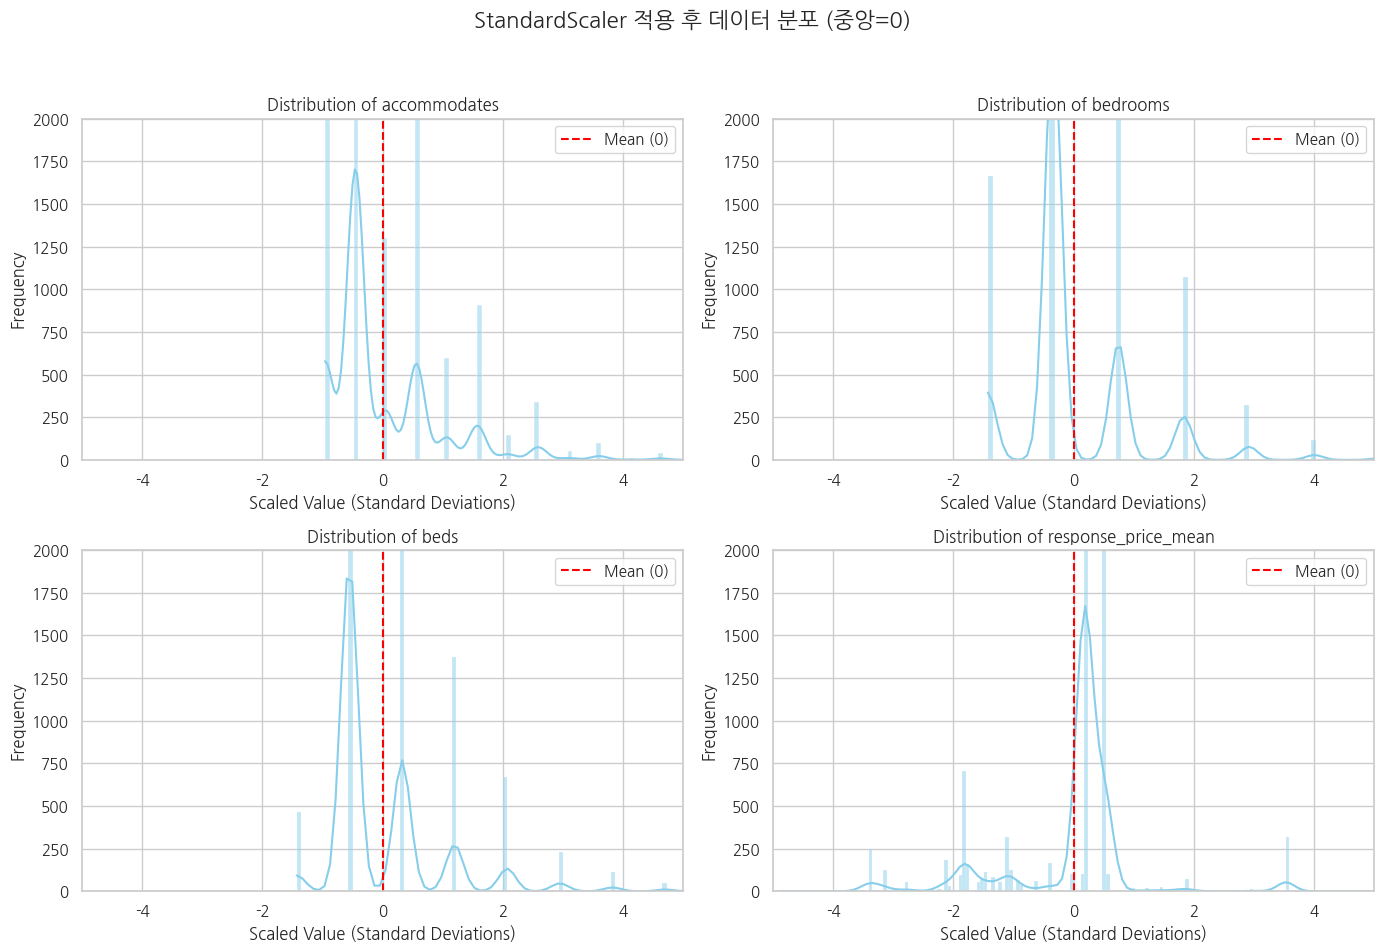

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('StandardScaler 적용 후 데이터 분포 (중앙=0)', fontsize=16)

for i, col in enumerate(scale_cols):
    row = i // 2
    col_idx = i % 2
    ax = axes[row, col_idx]
    
    sns.histplot(X_train_dum[col], kde=True, ax=ax, color='skyblue', edgecolor='white')
    
    ax.set_xlim(-5, 5)
    
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean (0)')
    
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Scaled Value (Standard Deviations)')
    ax.set_ylabel('Frequency')
    ax.set_ylim(0, 2000)
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

4-1. 여러 가지 가격 파생 컬럼 생성으로 인한 중복되는 의미 컬럼 drop <br>
모델 학습 시작! (lightGBM)

In [59]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LightGBM 회귀 모델 생성 및 하이퍼파라미터 세팅
lgbm_model = LGBMRegressor(
    n_estimators=100,      # 나무의 개수
    learning_rate=0.1,     # 학습률 (오답 수정 강도)
    num_leaves=31,         # 하나의 나무가 가질 수 있는 최대 잎(노드)의 개수
    random_state=42,       # 결과 고정
    n_jobs=-1              # 모든 CPU 코어 사용
)

In [60]:
lgbm_model.fit(X_train_dum, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 93
[LightGBM] [Info] Number of data points in the train set: 16468, number of used features: 7
[LightGBM] [Info] Start training from score 5.006864


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [61]:
# 평가 데이터로 예측 수행
y_pred_lgbm = lgbm_model.predict(X_test_dum)

In [62]:
# # 5. 채점을 위한 패키지 불러오기
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
# 실제 정답(y_test)과 모델이 적어낸 답(y_pred)을 비교하여 오차 계산
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("=== LightGBM 예측 결과 ===")
print(f"MAE (평균 절대 오차): {mae_lgbm:.4f}")
print(f"RMSE (평균 제곱근 오차): {rmse_lgbm:.4f}")
print(f"R2 Score (결정계수): {r2_lgbm:.4f}")

=== LightGBM 예측 결과 ===
MAE (평균 절대 오차): 0.3790
RMSE (평균 제곱근 오차): 0.5065
R2 Score (결정계수): 0.5709


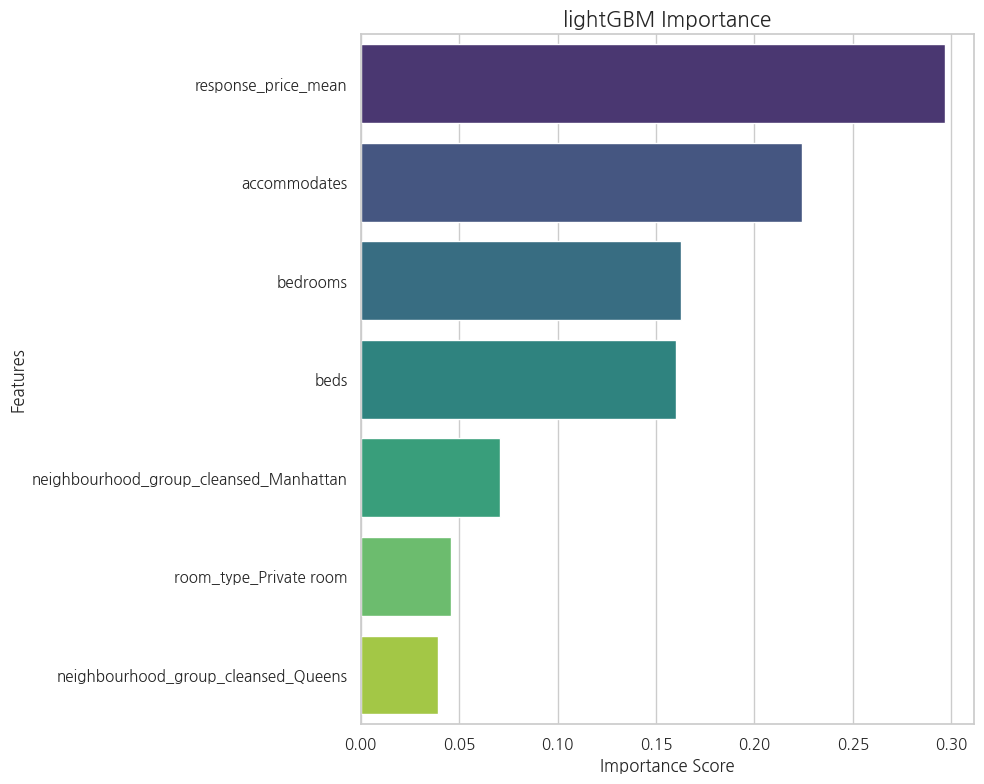

=== 특성 중요도 상위 10개 ===
                               Feature  Importance
                   response_price_mean    0.296667
                          accommodates    0.224333
                              bedrooms    0.162667
                                  beds    0.160333
neighbourhood_group_cleansed_Manhattan    0.071000
                room_type_Private room    0.045667
   neighbourhood_group_cleansed_Queens    0.039333


In [81]:
# 1. 모델이 계산한 특성 중요도(0~1 사이의 값)를 가져옵니다.
importances = lgbm_model.feature_importances_

# 💡 이 부분을 추가해 보세요! (전체 합으로 나누어 비율로 만들기)
importances_ratio = importances / importances.sum()

# 2. X_train의 컬럼명(피처 이름)을 가져옵니다.
feature_names = X_train_dum.columns

# 3. 보기 편하게 '피처 이름'과 '중요도'를 짝지어서 데이터프레임으로 만듭니다.
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances_ratio
})

# 4. 중요도가 높은 순서대로(내림차순) 정렬합니다.
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. 시각화 (그래프 그리기)
plt.figure(figsize=(10, 8)) # 그래프 크기 설정
# 상위 15개의 피처만 뽑아서 수평 막대 그래프로 그립니다.
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')

plt.title('lightGBM Importance', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 6. 정확한 수치로도 상위 10개를 출력해 봅니다.
print("=== 특성 중요도 상위 10개 ===")
print(feature_importance_df.head(10).to_string(index=False))

In [82]:
import numpy as np
import pandas as pd

my_listing = {
    'accommodates': 2,
    'bedrooms': 1,
    'beds': 2,
    'response_price_mean': 150.0, 
    'neighbourhood_group_cleansed': 'Brooklyn', 
    'room_type': 'Entire home/apt'
}

new_data = pd.DataFrame([my_listing])

cat_cols = ["neighbourhood_group_cleansed", "room_type"]
new_data_dum = pd.get_dummies(new_data, columns=cat_cols)

final_input = new_data_dum.reindex(columns=X_train_dum.columns, fill_value=0)

final_input[scale_cols] = scaler.transform(final_input[scale_cols])

# 예측 및 결과 출력
log_prediction = lgbm_model.predict(final_input)[0]
actual_price = np.expm1(log_prediction)

print(f"==========================================")
print(f"적정 숙박가: ${actual_price:.2f}")
print(f"==========================================")

적정 숙박가: $146.02
